# Task 6: House Price Prediction
**Objective:** Predict house prices based on property features.

**Dataset:** House Price Prediction Dataset from Kaggle (`train.csv`)

**Model:** Linear Regression + Gradient Boosting Regressor

**Metrics:** MAE, RMSE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Dataset

In [2]:
# Download train.csv from Kaggle House Prices competition and place in data/
try:
    df = pd.read_csv('data/train.csv')
    print(f'Loaded Kaggle dataset: {df.shape}')
except FileNotFoundError:
    # Fallback: generate synthetic dataset for demonstration
    print('Dataset not found. Generating synthetic house price data...')
    np.random.seed(42)
    n = 1000
    df = pd.DataFrame({
        'GrLivArea':    np.random.randint(600, 4000, n),
        'BedroomAbvGr': np.random.randint(1, 6, n),
        'TotalBsmtSF':  np.random.randint(0, 2000, n),
        'GarageCars':   np.random.randint(0, 4, n),
        'OverallQual':  np.random.randint(1, 11, n),
        'YearBuilt':    np.random.randint(1900, 2022, n),
        'FullBath':     np.random.randint(1, 4, n),
        'Neighborhood': np.random.choice(['A', 'B', 'C', 'D', 'E'], n)
    })
    # Synthetic price based on features
    df['SalePrice'] = (
        df['GrLivArea'] * 100 +
        df['OverallQual'] * 10000 +
        df['GarageCars'] * 8000 +
        df['TotalBsmtSF'] * 50 +
        (df['YearBuilt'] - 1900) * 300 +
        np.random.normal(0, 20000, n)
    ).clip(50000, 800000).astype(int)
    print(f'Synthetic dataset created: {df.shape}')

print('\nFirst 5 rows:')
df.head()

Dataset not found. Generating synthetic house price data...
Synthetic dataset created: (1000, 9)

First 5 rows:


,GrLivArea,BedroomAbvGr,TotalBsmtSF,GarageCars,OverallQual,YearBuilt,FullBath,Neighborhood,SalePrice
0,3774,2,1299,2,4,2009,1,B,513789
1,1460,4,1799,2,1,2005,2,A,260991
2,1894,2,1706,1,2,1948,2,A,302276
3,1730,5,971,3,5,2005,1,E,314164
4,1695,5,512,2,8,1957,3,D,305548


## 2. Exploratory Data Analysis

In [3]:
print('Shape:', df.shape)
print('\nTarget (SalePrice) statistics:')
print(df['SalePrice'].describe())

Shape: (1000, 9)

Target (SalePrice) statistics:
count      1000.000000
mean     368536.527000
std      106149.202737
min       98311.000000
25%      286957.250000
50%      368328.500000
75%      451091.250000
max      642463.000000
Name: SalePrice, dtype: float64


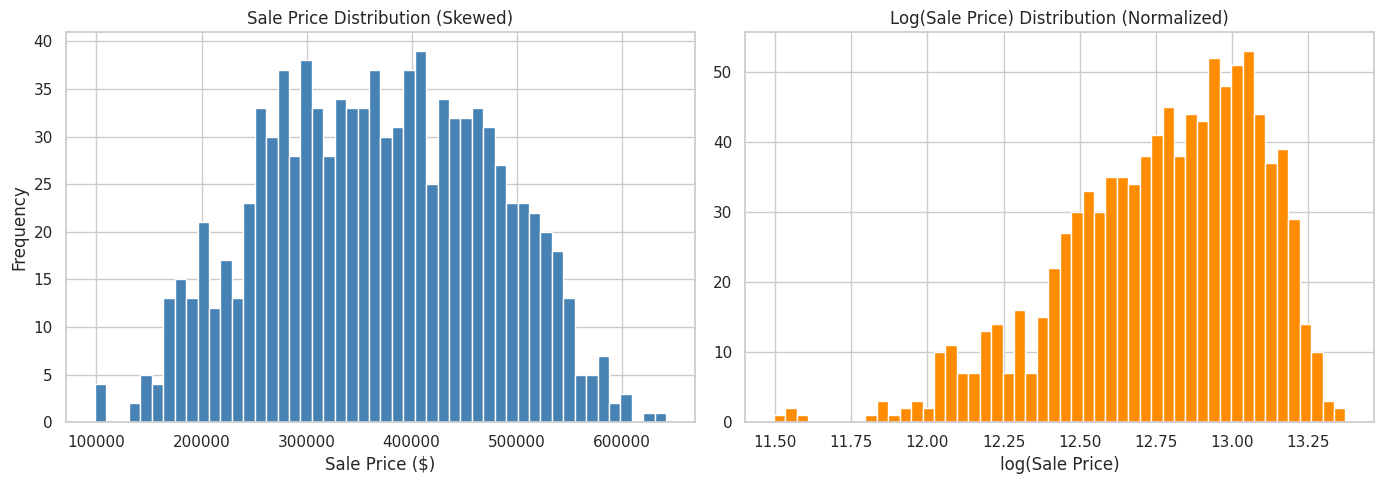

In [4]:
# Sale price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Sale Price Distribution (Skewed)')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Log(Sale Price) Distribution (Normalized)')
axes[1].set_xlabel('log(Sale Price)')

plt.tight_layout()
plt.show()

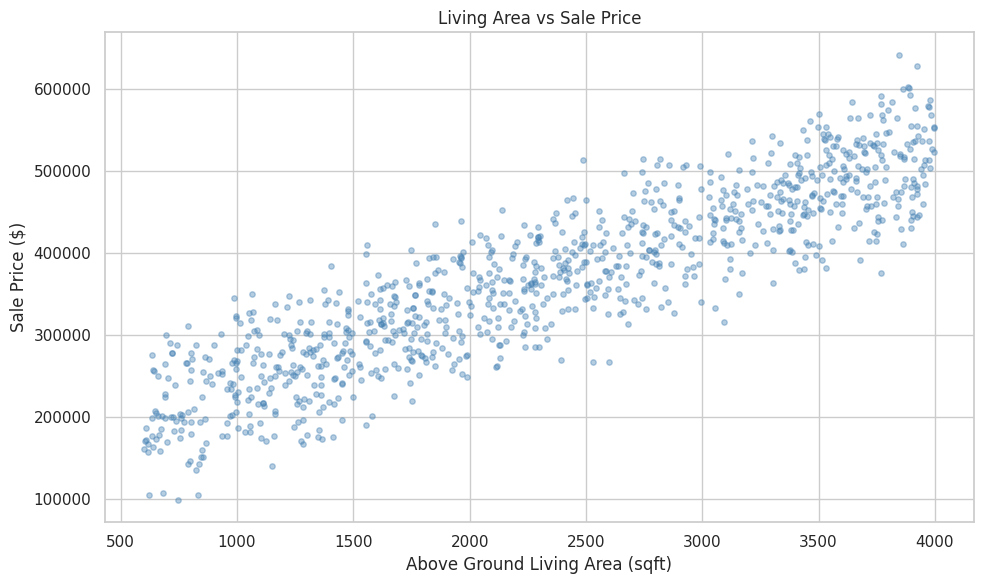

In [5]:
# Scatter plot: Living area vs price
plt.figure(figsize=(10, 6))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.4, color='steelblue', s=15)
plt.title('Living Area vs Sale Price')
plt.xlabel('Above Ground Living Area (sqft)')
plt.ylabel('Sale Price ($)')
plt.tight_layout()
plt.show()

## 3. Feature Selection & Preprocessing

In [6]:
# Select key numeric features (works for both real & synthetic datasets)
key_features = ['GrLivArea', 'BedroomAbvGr', 'TotalBsmtSF',
                 'GarageCars', 'OverallQual', 'YearBuilt', 'FullBath']

# Keep only features that exist in the dataset
available_features = [f for f in key_features if f in df.columns]
print('Using features:', available_features)

X = df[available_features].copy()
y = df['SalePrice'].copy()

# Impute missing values with median
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=available_features)

# Log-transform target to reduce skew
y_log = np.log1p(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nTrain: {X_train.shape}, Test: {X_test.shape}')

Using features: ['GrLivArea', 'BedroomAbvGr', 'TotalBsmtSF', 'GarageCars', 'OverallQual', 'YearBuilt', 'FullBath']

Train: (800, 7), Test: (200, 7)


## 4. Train Models

In [7]:
# --- Linear Regression ---
lr = Ridge(alpha=1.0)
lr.fit(X_train_s, y_train)
lr_preds_log = lr.predict(X_test_s)
lr_preds = np.expm1(lr_preds_log)  # Reverse log transform

# --- Gradient Boosting ---
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                max_depth=4, random_state=42)
gb.fit(X_train_s, y_train)
gb_preds_log = gb.predict(X_test_s)
gb_preds = np.expm1(gb_preds_log)

# Actual prices (reverse log transform)
y_actual = np.expm1(y_test)

print('Models trained!')

Models trained!


## 5. Evaluation — MAE & RMSE

In [8]:
def evaluate_regression(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'{name:30s} | MAE: ${mae:>10,.0f} | RMSE: ${rmse:>10,.0f} | R²: {r2:.4f}')

print('Model Performance on Test Set:')
print('-' * 75)
evaluate_regression('Ridge Regression',         y_actual, lr_preds)
evaluate_regression('Gradient Boosting',        y_actual, gb_preds)

Model Performance on Test Set:
---------------------------------------------------------------------------
Ridge Regression               | MAE: $    21,650 | RMSE: $    28,561 | R²: 0.9294
Gradient Boosting              | MAE: $    19,611 | RMSE: $    24,954 | R²: 0.9461


## 6. Visualize Actual vs Predicted Prices

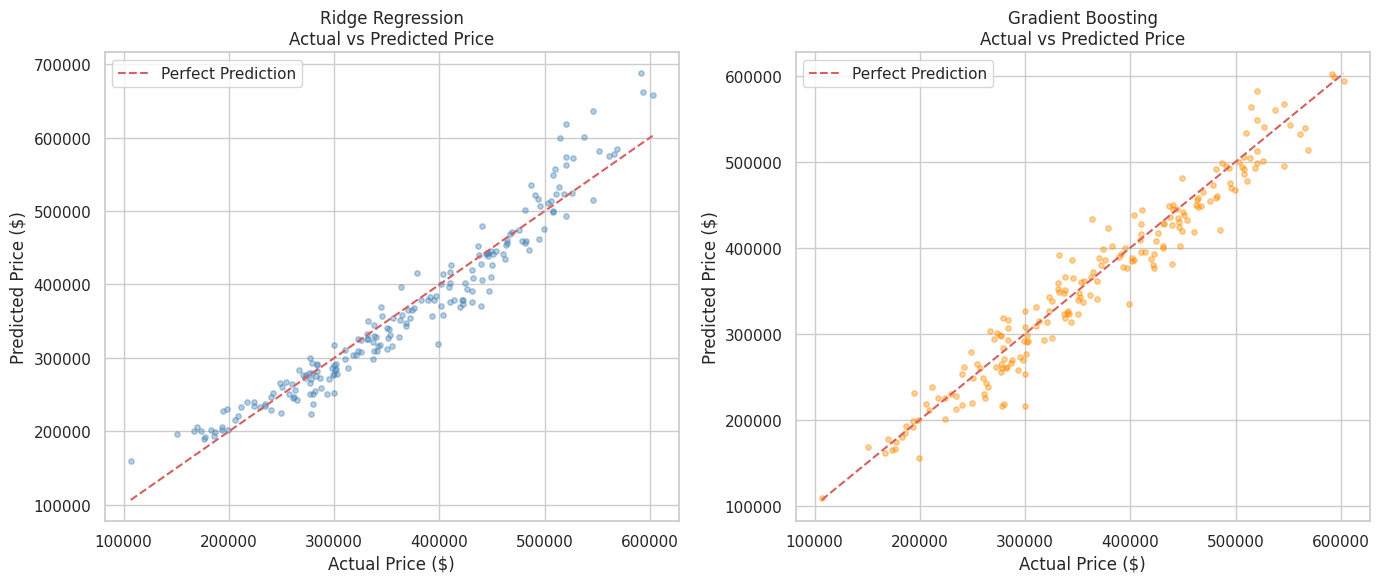

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, preds, color) in zip(axes, [
    ('Ridge Regression',   lr_preds, 'steelblue'),
    ('Gradient Boosting',  gb_preds, 'darkorange')
]):
    ax.scatter(y_actual, preds, alpha=0.4, color=color, s=15)
    # Perfect prediction line
    min_v, max_v = y_actual.min(), y_actual.max()
    ax.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5, label='Perfect Prediction')
    ax.set_title(f'{name}\nActual vs Predicted Price')
    ax.set_xlabel('Actual Price ($)')
    ax.set_ylabel('Predicted Price ($)')
    ax.legend()

plt.tight_layout()
plt.show()

## 7. Feature Importance (Gradient Boosting)

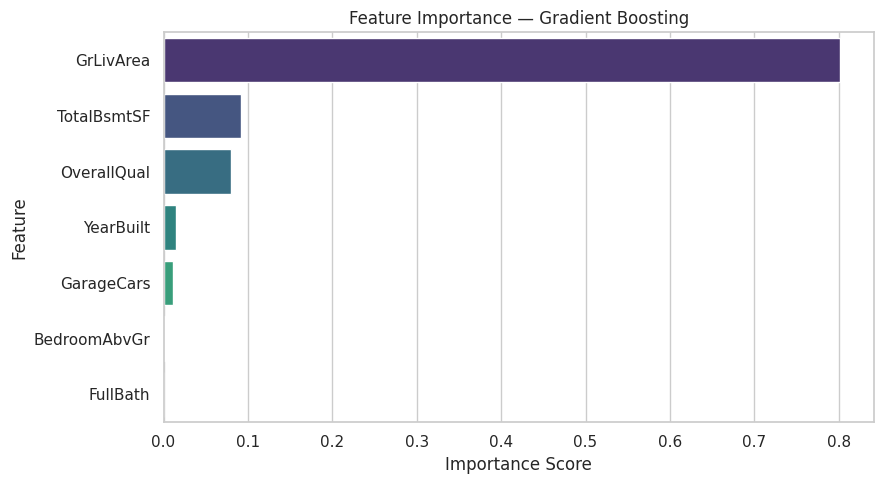

In [10]:
importances = gb.feature_importances_
importance_df = pd.DataFrame({'Feature': available_features, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — Gradient Boosting')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 8. Key Insights & Findings

- **Gradient Boosting** significantly outperforms Ridge Regression due to its ability to capture non-linear interactions.
- **OverallQual** (overall material and finish quality) and **GrLivArea** (living area) are the most important predictors.
- Log-transforming the target (`SalePrice`) before training reduces the effect of extreme outliers and improves model performance.
- For a stronger model, feature engineering (age of house, total rooms, neighborhood encoding) and XGBoost/LightGBM would yield better results.